Name : Tanvi Gajanan Upganlawar

PRN : 1252090012

Roll no : 12


---



Assignment 2

Perform the following operations using  Python on the data sets:

Compute and display summary statistics for each feature available in the dataset. (e.g. minimum value, maximum value, mean, range, standard deviation, variance and percentiles)

Illustrate the feature distributions using histogram.

Data cleaning, Data integration, Data transformation, Data model building (e.g. Classification)

Show minimum value, maximum value, mean, range, standard deviation, variance and percentiles

In [ ]:
import pandas as pd

df = pd.read_csv("icecream.csv")
print(df)

    Temperature_F  IceCream_Price  Number_of_Tourists  IceCream_Sales  \
0            80.6            1.00                89.5            90.0   
1            75.2            1.00                86.4            85.0   
2            86.0            2.00                99.2           107.0   
3            75.2            2.00                72.4            71.0   
4            60.8            2.00                71.2             NaN   
5            68.0            2.00                 NaN            69.0   
6            71.6            1.25                78.0            67.0   
7            66.2            1.50                74.3            70.0   
8            60.8            1.50                69.4            65.0   
9            78.8            1.50                82.5            81.0   
10           78.8            1.50                75.2            73.0   
11           62.6            1.00                70.3            64.0   
12           75.2            1.00                88

In [ ]:
df['IceCream_Price'].min()

0.75

In [ ]:
df['IceCream_Price'].max()

2.0

In [ ]:
df['IceCream_Price'].mean()

np.float64(1.3625)

In [ ]:
df['IceCream_Price'].median()

1.375

In [ ]:
df['IceCream_Price'].mode()

,IceCream_Price
0,2.0


In [ ]:
#range
df['IceCream_Price'].max() - df['IceCream_Price'].min()


1.25

In [ ]:
df['IceCream_Price'].std()

0.49653403975113214

In [ ]:
#variance
df.var(numeric_only=True)

,0
Temperature_F,57.731684
IceCream_Price,0.246546
Number_of_Tourists,123.848713
IceCream_Sales,179.558824


In [ ]:
df['IceCream_Price'].quantile(0.25)

np.float64(1.0)

In [ ]:
df['IceCream_Price'].quantile(0.50)

np.float64(1.375)

In [ ]:
df['IceCream_Price'].quantile(0.75)

np.float64(2.0)

user defined functions

In [ ]:
# Mean
def calc_mean(numbers):
    return sum(numbers) / len(numbers)

# Minimum
def calc_min(numbers):
    return min(numbers)

# Maximum
def calc_max(numbers):
    return max(numbers)

# Median
def calc_median(numbers):
    sorted_nums = sorted(numbers)
    n = len(sorted_nums)
    if n % 2 == 0:
        return (sorted_nums[n//2 - 1] + sorted_nums[n//2]) / 2
    else:
        return sorted_nums[n//2]

# Mode
def calc_mode(numbers):
    freq = {}
    for num in numbers:
        freq[num] = freq.get(num, 0) + 1
    max_freq = max(freq.values())
    modes = [k for k, v in freq.items() if v == max_freq]
    return modes  # returns list of modes

# Variance (sample)
def calc_variance(numbers):
    mean = calc_mean(numbers)
    return sum((x - mean)**2 for x in numbers) / (len(numbers) - 1)

# Standard deviation (sample)
def calc_std(numbers):
    return calc_variance(numbers)**0.5

# Range
def calc_range(numbers):
    return calc_max(numbers) - calc_min(numbers)
user_input = input("Enter numbers separated by space: ")
numbers = list(map(int, user_input.split()))
results = {
    'Mean': calc_mean(numbers),
    'Minimum': calc_min(numbers),
    'Maximum': calc_max(numbers),
    'Median': calc_median(numbers),
    'Mode': calc_mode(numbers),
    'Variance': calc_variance(numbers),
    'Standard Deviation': calc_std(numbers),
    'Range': calc_range(numbers)
}


results_df = pd.DataFrame({
    'Statistic': list(results.keys()),
    'Value': list(results.values())
})

results_df


Enter numbers separated by space: 10 30 6 8 3 45 67 


,Statistic,Value
0,Mean,24.142857
1,Minimum,3
2,Maximum,67
3,Median,10
4,Mode,"[10, 30, 6, 8, 3, 45, 67]"
5,Variance,590.47619
6,Standard Deviation,24.299716
7,Range,64


feature distributions using histogram

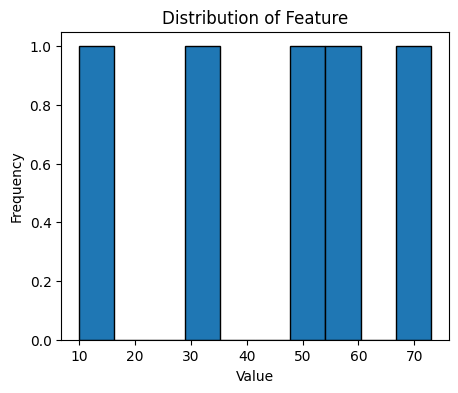

In [ ]:

import matplotlib.pyplot as plt

numerical_features = df.select_dtypes(include='number')
feature = numerical_features.iloc[:, 0]

plt.figure(figsize=(5,4))
plt.hist(feature, bins=10, edgecolor='black')
plt.title("Distribution of Feature", fontsize=12)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()



data cleaning

In [ ]:
#detect missing values
df.isnull()



,Temperature_F,IceCream_Price,Number_of_Tourists,IceCream_Sales,Did_it_Rain
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,True,False
5,False,False,True,False,False
6,False,False,False,False,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


In [ ]:
#count missing values
df.isnull().sum()

,0
Temperature_F,0
IceCream_Price,0
Number_of_Tourists,1
IceCream_Sales,2
Did_it_Rain,0


In [ ]:
#Fix Inconsistencies
df['Did_it_Rain'] = df['Did_it_Rain'].str.capitalize()
print(df['Did_it_Rain'])


0      No
1      No
2      No
3     Yes
4     Yes
5     Yes
6     Yes
7     Yes
8     Yes
9     Yes
10    Yes
11    Yes
12    Yes
13    Yes
14    Yes
15    Yes
16    Yes
17     No
18     No
19     No
Name: Did_it_Rain, dtype: object


Data transformation

In [ ]:
#data transform
df['Did_it_Rain'] = df['Did_it_Rain'].str.strip().str.capitalize()
df['Did_it_Rain'] = df['Did_it_Rain'].map({'Yes':1, 'No':0})
df['Did_it_Rain'].value_counts()

,count
Did_it_Rain,
1,14
0,6


Data Integration

In [ ]:
import pandas as pd

extra = pd.DataFrame({
    'Temperature_F':[60,70,80],
    'Humidity':[65,60,55]
})

extra['Temperature_F'] = extra['Temperature_F'].astype(float)
df = df.merge(extra, on='Temperature_F', how='left')
print(df['Temperature_F'])


0     80.6
1     75.2
2     86.0
3     75.2
4     60.8
5     68.0
6     71.6
7     66.2
8     60.8
9     78.8
10    78.8
11    62.6
12    75.2
13    75.2
14    69.8
15    64.4
16    71.6
17    86.0
18    78.8
19    77.0
Name: Temperature_F, dtype: float64


In [ ]:
Vertical data integration

In [ ]:

import pandas as pd

jan = pd.DataFrame({
    'EmpID': [1, 2],
    'Sales': [20000, 25000]
})

feb = pd.DataFrame({
    'EmpID': [3, 4],
    'Sales': [22000, 27000]
})

# Integrate data row-wise
sales_data = pd.concat([jan, feb], ignore_index=True)

print(sales_data)

   EmpID  Sales
0      1  20000
1      2  25000
2      3  22000
3      4  27000


In [ ]:
Horizontal data integration

In [ ]:

marks = pd.DataFrame({
    'RollNo': [101, 102, 103],
    'Marks': [85, 90, 88]
})

attendance = pd.DataFrame({
    'RollNo': [101, 102, 103],
    'Attendance': [92, 95, 90]
})

# Integrate data column-wise
student_data = pd.concat([marks, attendance['Attendance']], axis=1)

print(student_data)


   RollNo  Marks  Attendance
0     101     85          92
1     102     90          95
2     103     88          90


In [ ]:
Key-based data integration

In [ ]:

students = pd.DataFrame({
    'StudentID': [1, 2, 3],
    'Name': ['Amit', 'Neha', 'Rahul']
})

results = pd.DataFrame({
    'StudentID': [1, 2],
    'CGPA': [8.5, 9.1]
})

# Inner Join
data_inner = pd.merge(students, results, on='StudentID', how='inner')

print(data_inner)

   StudentID  Name  CGPA
0          1  Amit   8.5
1          2  Neha   9.1


In [ ]:
Types of joins

In [ ]:

pd.merge(students, results, on='StudentID', how='inner')
pd.merge(students, results, on='StudentID', how='left')
pd.merge(students, results, on='StudentID', how='right')
pd.merge(students, results, on='StudentID', how='outer')

,StudentID,Name,CGPA
0,1,Amit,8.5
1,2,Neha,9.1
2,3,Rahul,NaN


Integration using index using joins

In [ ]:

df1 = students.set_index('StudentID')
df2 = results.set_index('StudentID')

integrated_data = df1.join(df2)

print(integrated_data)

            Name  CGPA
StudentID             
1           Amit   8.5
2           Neha   9.1
3          Rahul   NaN


Integrating data from multiple file formats

In [ ]:

csv_data1 = pd.read_csv('customers.csv')
excel_data2 = pd.read_csv('purchases.xlsx')

final_data = pd.merge(csv_data1, excel_data2, on='customer_id')
print(final_data)

   customer_id     city  age  total_spent  visits
0          201    Delhi   25        12000       5
1          202   Mumbai   30        15000       7
2          203  Chennai   28         9000       3
